# **TEXT CLASSIFICATION AND SENTIMENT ANALYSIS**

In [1]:
!pip install wordcloud

In [2]:
import nltk
nltk.download('all')

[nltk_data] Downloading collection 'all'
[nltk_data]    | 
[nltk_data]    | Downloading package abc to /root/nltk_data...
[nltk_data]    |   Package abc is already up-to-date!
[nltk_data]    | Downloading package alpino to /root/nltk_data...
[nltk_data]    |   Package alpino is already up-to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Package averaged_perceptron_tagger is already up-
[nltk_data]    |       to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger_eng to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Package averaged_perceptron_tagger_eng is already
[nltk_data]    |       up-to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger_ru to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Package averaged_perceptron_tagger_ru is already
[nltk_data]    |       up-to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger_r

True

In [3]:
import pandas as pd
import numpy as np
import re
import string
import matplotlib.pyplot as plt
from wordcloud import WordCloud, STOPWORDS
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import CountVectorizer,TfidfTransformer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

In [4]:
df=pd.read_csv('amazonreviews.tsv', sep="\t")
df.head()

,label,review
0,pos,Stuning even for the non-gamer: This sound tra...
1,pos,The best soundtrack ever to anything.: I'm rea...
2,pos,Amazing!: This soundtrack is my favorite music...
3,pos,Excellent Soundtrack: I truly like this soundt...
4,pos,"Remember, Pull Your Jaw Off The Floor After He..."


*Data Cleaning:**

In [5]:
df.shape

(10000, 2)

In [6]:
### removing unneccessary space before and after line
df["review"] = df["review"].str.strip()

In [7]:
## missing value
df.isna().sum()

,0
label,0
review,0


In [8]:
## duplicate value
df.duplicated().sum()

np.int64(0)

In [9]:
df['len']= df['review'].apply(len)

In [10]:
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

In [11]:
## preprocessing
def preprocess(text):
    # lowercasing
    text = text.lower()
    # remove numbers, punctuation, special symbols
    text = re.sub(r"[^a-z\s]", "", text)
    # tokenize
    words = text.split()
    # remove stopwords
    words = [word for word in words if word not in stop_words]
    # lemmatization
    words = [lemmatizer.lemmatize(word) for word in words]
    return " ".join(words)

In [12]:
## apply
df['clean_review'] = df['review'].apply(preprocess)

**Exploratory Analysis:**

label
neg    5097
pos    4903
Name: count, dtype: int64


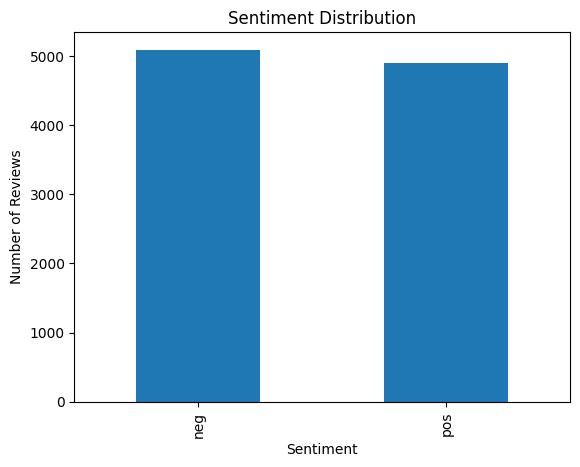

In [13]:
## plotting label count
print(df['label'].value_counts())
df['label'].value_counts().plot(kind='bar')
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.show()

The dataset contains 5097 negative reviews and 4903 positive reviews, indicating a well-balanced dataset. Since both classes are almost equally represented, the model will be able to learn both positive and negative patterns without bias. The bar chart visually confirms that the dataset does not suffer from class imbalance.



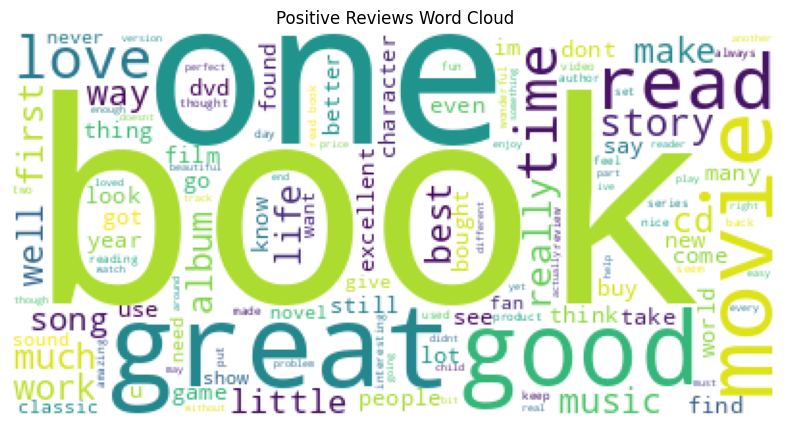

In [14]:
## positive wordcloud
positive_text = " ".join(df[df['label'] == 'pos']['clean_review'])
plt.figure(figsize=(10,5))
plt.imshow(WordCloud(stopwords=STOPWORDS, background_color='white').generate(positive_text))
plt.axis('off')
plt.title("Positive Reviews Word Cloud")
plt.show()


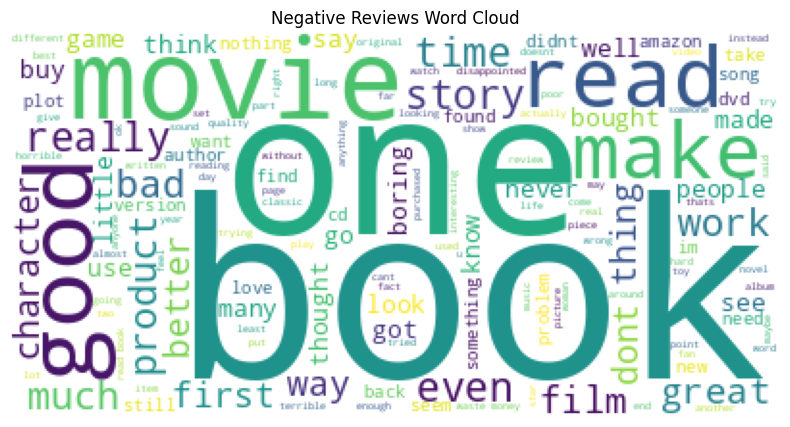

In [15]:
# Negative Word Cloud
negative_text = " ".join(df[df['label'] == 'neg']['clean_review'])
plt.figure(figsize=(10,5))
plt.imshow(WordCloud(stopwords=STOPWORDS, background_color='white').generate(negative_text))
plt.axis('off')
plt.title("Negative Reviews Word Cloud")
plt.show()

The dataset contains strong linguistic cues such as great, love, and excellent in positive reviews, and bad, boring, and waste in negative reviews. These cues help the machine-learning model accurately distinguish between sentiments.

In [16]:
from collections import Counter

In [17]:
## most common positive words
pos_words = positive_text.split()
pos_common = Counter(pos_words).most_common(20)
pos_common

[('book', 3861),
 ('great', 2089),
 ('one', 1936),
 ('good', 1638),
 ('read', 1574),
 ('like', 1320),
 ('movie', 1295),
 ('time', 1135),
 ('love', 1036),
 ('would', 943),
 ('get', 936),
 ('well', 857),
 ('story', 857),
 ('really', 827),
 ('best', 801),
 ('first', 708),
 ('make', 705),
 ('work', 679),
 ('year', 677),
 ('much', 650)]

In [18]:
## most common negative words
neg_words = negative_text.split()
neg_common = Counter(neg_words).most_common(20)
neg_common

[('book', 3683),
 ('one', 2119),
 ('movie', 1732),
 ('like', 1570),
 ('would', 1438),
 ('get', 1285),
 ('time', 1274),
 ('dont', 1240),
 ('read', 1238),
 ('good', 1137),
 ('even', 898),
 ('buy', 821),
 ('really', 778),
 ('much', 769),
 ('make', 761),
 ('work', 761),
 ('story', 755),
 ('bad', 749),
 ('money', 746),
 ('first', 736)]

**Model Development:**

In [19]:
features=df['clean_review']
target=df['label']

In [20]:
## train_test_split
x_train,x_test,y_train,y_test=train_test_split(features,target,test_size=0.2,random_state=42)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(8000,)
(2000,)
(8000,)
(2000,)


In [21]:
from sklearn.pipeline import Pipeline

In [22]:
## pipeline -countvec,tfidf,logreg
pipeline = Pipeline([
    ('count', CountVectorizer()),
    ('tfidf', TfidfTransformer()),
    ('model', LogisticRegression(max_iter=300))
])

In [23]:
## train
pipeline.fit(x_train, y_train)

Pipeline(steps=[('count', CountVectorizer()), ('tfidf', TfidfTransformer()),
                ('model', LogisticRegression(max_iter=300))])

In [24]:
y_pred = pipeline.predict(x_test)

**Validation:**

In [25]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

In [26]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, pos_label='pos'))
print("Recall   :", recall_score(y_test, y_pred, pos_label='pos'))
print("F1-score :", f1_score(y_test, y_pred, pos_label='pos'))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.846
Precision: 0.8379772961816305
Recall   : 0.8431983385254413
F1-score : 0.8405797101449275

Classification Report:
               precision    recall  f1-score   support

         neg       0.85      0.85      0.85      1037
         pos       0.84      0.84      0.84       963

    accuracy                           0.85      2000
   macro avg       0.85      0.85      0.85      2000
weighted avg       0.85      0.85      0.85      2000


Confusion Matrix:
 [[880 157]
 [151 812]]


In [27]:
## cross validation
from sklearn.model_selection import cross_val_score

In [28]:
cv_scores = cross_val_score(pipeline, features, target, cv=5, scoring='accuracy')

In [29]:
print("Cross-Validation Scores:", cv_scores)
print("Mean CV Accuracy:", cv_scores.mean())

Cross-Validation Scores: [0.8475 0.8205 0.816  0.8235 0.8495]
Mean CV Accuracy: 0.8314


The TF-IDF + Logistic Regression model achieved a strong test accuracy of 84.6%, with balanced precision, recall, and F1-scores for both positive and negative classes (all around 84–85%). The confusion matrix shows that most reviews were correctly classified, indicating reliable performance. Additionally, 5-fold cross-validation produced a mean accuracy of 83.14%, which is close to the test accuracy, confirming that the model is stable, generalizes well, and does not overfit.

---



#**comprehensive report**

This project focuses on building an automated sentiment analysis system to classify Amazon customer reviews as either positive or negative. Customer reviews contain rich information that reflects satisfaction levels and product performance, but due to the large volume of reviews received daily, manual analysis becomes inefficient. An automated model helps monitor customer sentiment in real time, identify sudden increases in negative feedback, and support product teams in making data-driven decisions to improve customer satisfaction.

The dataset used for this analysis contains 10,000 customer reviews, each consisting of a sentiment label (“pos” or “neg”) and the written review text. The dataset is nearly balanced, with 5097 negative reviews and 4903 positive reviews, ensuring that the model does not become biased toward one class. Before modeling, extensive preprocessing was performed. This included removing duplicates, handling missing values, converting text to lowercase, and removing punctuation, numbers, special characters, and stopwords. Lemmatization was applied to reduce words to their base form, and a cleaned version of each review was created for further analysis. These steps ensured that the dataset was clean, consistent, and suitable for NLP models.

Exploratory Data Analysis (EDA) was conducted to understand sentiment patterns within the text. Word clouds for positive and negative reviews showed strong linguistic cues—positive reviews frequently included terms such as “great,” “love,” and “excellent,” while negative reviews contained words like “bad,” “boring,” and “waste.” The dataset’s balanced distribution and the presence of clear sentiment-bearing words indicated that it was appropriate for machine learning–based sentiment classification.

For model development, a TF-IDF + Logistic Regression pipeline was chosen. TF-IDF effectively transforms text into numerical features by highlighting words important for sentiment, while Logistic Regression is efficient, interpretable, and works very well for high-dimensional text data. The model was trained using 80% of the dataset and evaluated on the remaining 20%. The chosen pipeline achieved strong performance, confirming that TF-IDF features provide good linear separability for this classification task.

Model validation involved both train–test evaluation and cross-validation. On the test set, the model achieved 84.6% accuracy, with precision, recall, and F1-scores all around 84% for both positive and negative reviews. The confusion matrix showed that the majority of reviews were correctly classified, demonstrating reliable performance across both classes. To assess the stability of the model, five-fold cross-validation was performed. The mean cross-validation accuracy was 83.14%, which is very close to the test accuracy, indicating that the model generalizes well and does not suffer from overfitting.

In conclusion, the sentiment analysis model developed in this project successfully classifies customer reviews with high accuracy and stability. The analysis revealed distinct linguistic patterns in positive and negative reviews, and the TF-IDF + Logistic Regression model proved effective for this type of text classification task. From a business perspective, deploying this model can significantly improve customer satisfaction monitoring by identifying negative sentiment early, enabling faster responses to issues, and providing valuable insights for product improvement. Future enhancements could include experimenting with more advanced models such as BERT, expanding to multi-class sentiment levels, and integrating the model into a real-time review monitoring dashboard.